In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
import sys
print(sys.version)


3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [3]:
import pandas as pd
import numpy as np


In [4]:
train_df = pd.read_csv("../dataset/KDDTrain+.csv")

print("Training data loaded")
print(train_df.shape)


Training data loaded
(125973, 38)


In [5]:
print("Number of columns:", train_df.shape[1])
train_df.head()


Number of columns: 38


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,classnum
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
train_df.columns


Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted',
       'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
       'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
       'serror_rate', 'srv_serror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'dst_host_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class', 'classnum'],
      dtype='object')

In [7]:
# Target column
y = train_df["class"]

# Drop label columns from features
X = train_df.drop(["class", "classnum"], axis=1)


In [8]:
categorical_cols = ["protocol_type", "service", "flag"]


In [9]:
X = pd.get_dummies(X, columns=categorical_cols)


In [10]:
y = y.apply(lambda x: 0 if x == "normal" else 1)


In [11]:
print("Final feature shape:", X.shape)
print("Label distribution:")
print(y.value_counts())


Final feature shape: (125973, 117)
Label distribution:
class
0    67343
1    58630
Name: count, dtype: int64


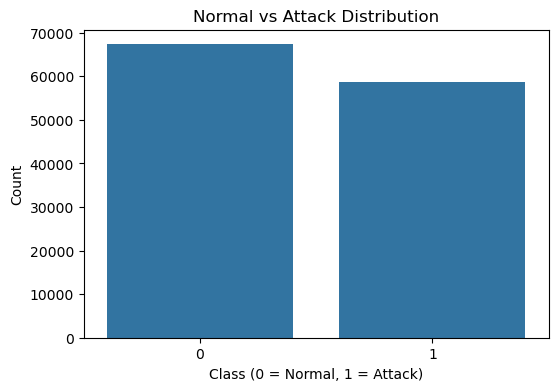

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Normal vs Attack Distribution")
plt.xlabel("Class (0 = Normal, 1 = Attack)")
plt.ylabel("Count")
plt.show()


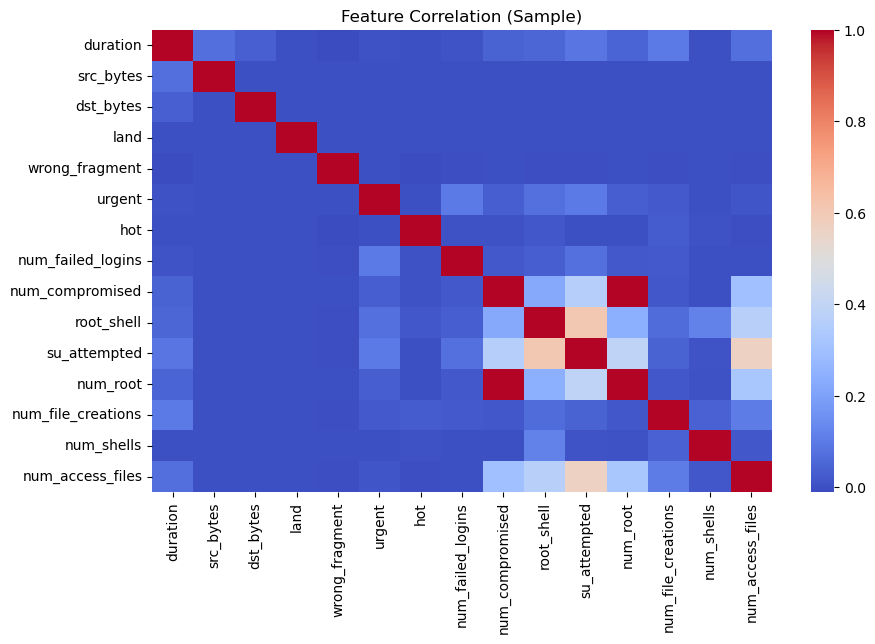

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(X.iloc[:, :15].corr(), cmap="coolwarm")
plt.title("Feature Correlation (Sample)")
plt.show()


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (100778, 117)
Testing samples: (25195, 117)


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=0.3,
    random_state=42
)

rf.fit(X_train, y_train)

rf_acc = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest Accuracy:", rf_acc)

Training Random Forest...
Random Forest Accuracy: 0.9944433419329232


In [16]:
from sklearn.linear_model import SGDClassifier

print("Training Linear SVM (SGD)...")

svm = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    random_state=42
)

svm.fit(X_train, y_train)

svm_acc = accuracy_score(y_test, svm.predict(X_test))

print("Linear SVM Accuracy:", svm_acc)

Training Linear SVM (SGD)...
Linear SVM Accuracy: 0.25163722960904944


In [17]:
from sklearn.neural_network import MLPClassifier

print("Training MLP...")

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=150,
    random_state=42
)

mlp.fit(X_train, y_train)

mlp_acc = accuracy_score(y_test, mlp.predict(X_test))

print("MLP Accuracy:", mlp_acc)

Training MLP...
MLP Accuracy: 0.9505060527882516


In [18]:
from sklearn.ensemble import AdaBoostClassifier

print("Training AdaBoost...")

ada = AdaBoostClassifier(
    n_estimators=30,
    random_state=42
)

ada.fit(X_train, y_train)

ada_acc = accuracy_score(y_test, ada.predict(X_test))

print("AdaBoost Accuracy:", ada_acc)

Training AdaBoost...


d:\anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Accuracy: 0.9835284778725938


In [19]:
print("rf_acc exists:", 'rf_acc' in globals())
print("svm_acc exists:", 'svm_acc' in globals())
print("mlp_acc exists:", 'mlp_acc' in globals())
print("ada_acc exists:", 'ada_acc' in globals())

rf_acc exists: True
svm_acc exists: True
mlp_acc exists: True
ada_acc exists: True


In [20]:
total = rf_acc + svm_acc + mlp_acc + ada_acc

weights = {
    "rf": rf_acc / total,
    "svm": svm_acc / total,
    "mlp": mlp_acc / total,
    "ada": ada_acc / total
}

print("Model Weights:", weights)

Model Weights: {'rf': 0.3127067134281043, 'svm': 0.07912834017697791, 'mlp': 0.29889045592401686, 'ada': 0.30927449047090105}


In [21]:
import pickle

with open("../model/rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("../model/svm_model.pkl", "wb") as f:
    pickle.dump(svm, f)

with open("../model/mlp_model.pkl", "wb") as f:
    pickle.dump(mlp, f)

with open("../model/ada_model.pkl", "wb") as f:
    pickle.dump(ada, f)

with open("../model/model_weights.pkl", "wb") as f:
    pickle.dump(weights, f)

print("All ensemble models and weights saved successfully!")

All ensemble models and weights saved successfully!


In [22]:
import sys
print(sys.executable)

import sklearn
print(sklearn.__version__)

d:\anaconda\python.exe
1.5.1
